In [278]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import acf as sm_acf
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:.6f}'.format

### Задание 5. Модели AR ###

#### *1. Временной ряд описывается авторегрессионной моделью $y_t - 0.3y_{t-1} + 0.5y{t-2} = \varepsilon_t$* ####

#### - *Определите, будет ли этот ряд стационарным.*
#### - *Выпишите рекуррентную формулу для автокорреляционной функции (ACF) и постройте ее график (используйте функцию stem()).*
#### - (*) *Найдите аналитическое выражение для ACF и сравните его график с предыдущим методом*

*Проверка на стационарность*

Рассматривается авторегрессионный процесс второго порядка:
$
y_t = 0.3 y_{t-1} - 0.5 y_{t-2} + \varepsilon_t,
$
где $ \varepsilon_t \sim \text{N}(0, \sigma^2) $ — белый шум.

Модель AR(2) можно записать в операторной форме:
$$
(1 - a_1 L - a_2 L^2) y_t = \varepsilon_t,
$$
где $ L $ — лаговый оператор: $ L y_t = y_{t-1} $. Подставляя коэффициенты $ a_1 = 0.3 $, $ a_2 = -0.5 $, получаем:
$$
(1 - 0.3L + 0.5L^2) y_t = \varepsilon_t.
$$

Составим характеристическое уравнение, заменив $ L \rightarrow z $:
$$
A(z) = 1 - 0.3z + 0.5z^2 = 0 \quad \Leftrightarrow \quad 0.5z^2 - 0.3z + 1 = 0.
$$

Найдём корни:
$$
z_{1,2} = \frac{0.3 \pm \sqrt{(-0.3)^2 - 4 \cdot 0.5 \cdot 1}}{2 \cdot 0.5}
= \frac{0.3 \pm \sqrt{-1.91}}{1}
= 0.3 \pm i \cdot \sqrt{1.91}.
$$

Вычислим модуль корней:
$$
|z| = \sqrt{0.3^2 + (\sqrt{1.91})^2} = \sqrt{0.09 + 1.91} = \sqrt{2} \approx 1.41 > 1.
$$

*Вывод:* оба корня лежат вне единичного круга, следовательно, процесс *стационарный*.


*Рекурентная формула*

Для AR(2)-процесса автокорреляционная функция $\rho_k $ рассчитывается по системе Юла–Уокера:
$$
\begin{cases}
\rho_0 = 1, \\
\rho_1 = a_1 + a_2\rho_1 \Rightarrow  \rho_1 = \dfrac{a_1}{1 - a_2}, \\
\rho_2 = a_1 \rho_1 + a_2, \\
\rho_k = a_1 \rho_{k-1} + a_2 \rho_{k-2}, \quad k \geq 3.
\end{cases}
$$

Подставим значения:
$$
\begin{cases}
\rho_0 = 1, \\
\rho_1 = \rho_1 = \dfrac{0.3}{1 + 0.5} = 0.2, \\
\rho_2 = 0.3 \rho_1 - 0.5, \\
\rho_k = 0.3 \rho_{k-1} - 0.5 \rho_{k-2}, \quad k \geq 3.
\end{cases}
$$

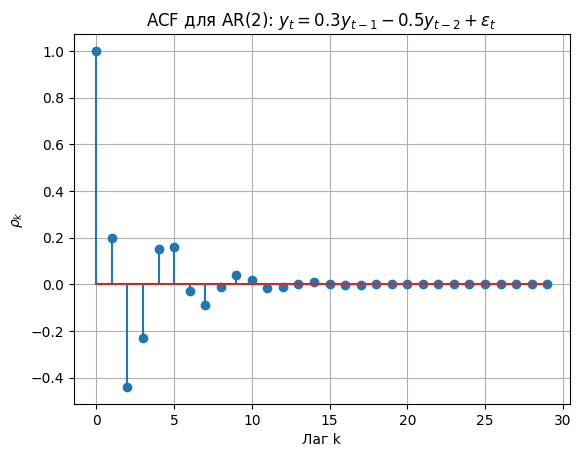

In [279]:
a1, a2 = 0.3, -0.5
n_lags = 30
acf = np.zeros(n_lags)
acf[0] = 1
acf[1] = a1 / (1 - a2)
acf[2] = a1 * acf[1] + a2
for k in range(3, 20):
    acf[k] = a1 * acf[k - 1] + a2 * acf[k - 2]

plt.stem(range(n_lags), acf)
plt.title("ACF для AR(2): $y_t = 0.3 y_{t-1} - 0.5 y_{t-2} + \\varepsilon_t$")
plt.xlabel("Лаг k")
plt.ylabel("$\\rho_k$")
plt.grid(True)
plt.show()


Для анализа ACF найдём корни характеристического уравнения:
$$
z^2 - a_1 z - a_2 = 0.
$$

Пусть корни уравнения — комплексно сопряжённые:
$$
z_{1,2} = r e^{\pm i\theta},
$$
где $ r = |z| $ — модуль корня, $ \theta = \arg(z) $ — аргумент (фаза).

Общее решение однородного рекуррентного уравнения для автоковариации $ \gamma_k $ будет линейной комбинацией степеней корней:
$$
\gamma_k = A \cdot z_1^k + B \cdot z_2^k = r^k \left( A e^{i k \theta} + B e^{-i k \theta} \right),
$$
так как $ z_1 = r e^{i\theta}, \quad z_2 = r e^{-i\theta} $.

Поскольку автоковариационная функция должна быть вещественной, выберем $ B = \overline{A} $, тогда:
$$
\gamma_k = 2r^k \cdot \Re \left( A e^{i k \theta} \right) = C \cdot r^k \cos(k\theta),
$$
где $ C = 2|A| \cos(\phi) $ — вещественная константа.

Нормируя на дисперсию $ \gamma_0 $, получаем аналитическое выражение автокорреляционной функции:
$$
\boxed{
\rho_k = r^k \cdot \cos(k\theta), \quad k \geq 0
}
$$

*Пример для $a_1 = 0.3,\; a_2 = -0.5$*

Характеристическое уравнение:
$$
z^2 - 0.3z + 0.5 = 0
\Rightarrow z_{1,2} = 0.15 \pm i \cdot 0.691
$$

Модуль:
$$
r = |z| = \sqrt{0.15^2 + 0.691^2} = \sqrt{0.5} \approx 0.707
$$

Аргумент:
$$
\theta = \arg(z) = \arctan\left( \frac{0.691}{0.15} \right) \approx 1.357 \text{ рад}
$$

Следовательно, аналитическое выражение:
$$
\rho_k = (0.707)^k \cdot \cos(1.357 \cdot k)
$$

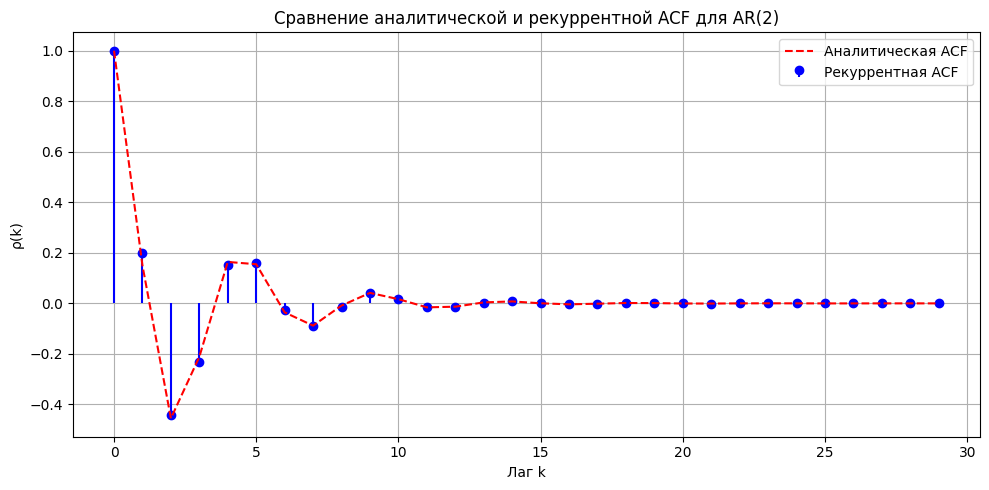

In [280]:
a1 = 0.3
a2 = -0.5

coeffs = [1, -a1, -a2]
roots = np.roots(coeffs)

z1 = roots[0]
r = np.abs(z1)
theta = np.angle(z1)

rho0 = 1
rho1 = a1 / (1 - a2)

acf_analytic = np.array([r**k * np.cos(k * theta) for k in range(n_lags)])

acf_recur = np.zeros(n_lags)
acf_recur[0] = 1
acf_recur[1] = rho1
acf_recur[2] = a1 * acf_recur[1] + a2
for k in range(3, n_lags):
    acf_recur[k] = a1 * acf_recur[k - 1] + a2 * acf_recur[k - 2]

plt.figure(figsize=(10, 5))
plt.stem(range(n_lags), acf_recur, linefmt='b-', markerfmt='bo', basefmt=" ", label="Рекуррентная ACF")
plt.plot(range(n_lags), acf_analytic, 'r--', label="Аналитическая ACF")
plt.title("Сравнение аналитической и рекуррентной ACF для AR(2)")
plt.xlabel("Лаг k")
plt.ylabel("ρ(k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### *2. По серии измерений давления $P$ в абсорбере вычислите разности давлений $\Delta P$ . Постройте авторегрессионную модель $AR(p)$. Для этого:* ####

- постройте графики выборочных $ACF$ и $PACF$ для $\Delta P$ , оцените порядок модели $p$;

In [281]:
df = pd.read_excel("TimeSeries.xls", header=None)[2:].astype(float)
P = df.iloc[:, 0].values.flatten()[1:]
time = np.arange(len(P)) * 4

In [282]:
dP = np.diff(P)
time_dP = time[1:]

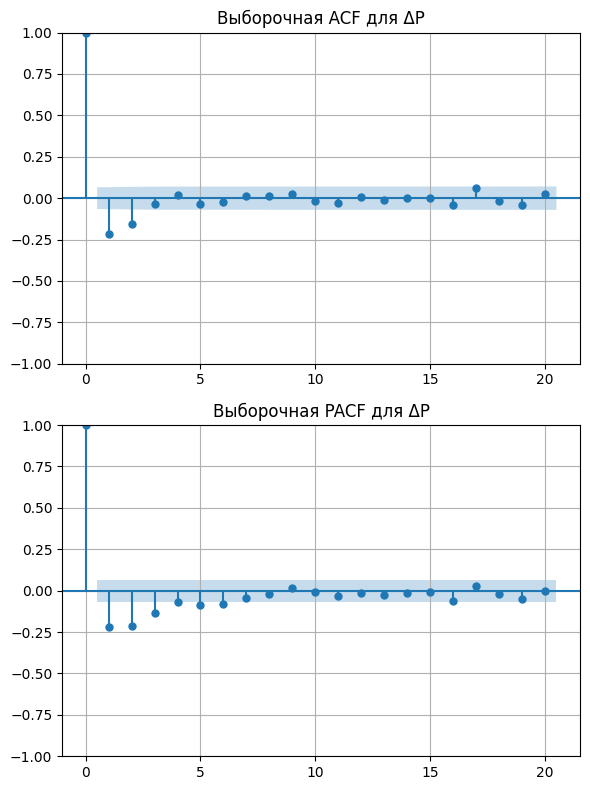

In [283]:
nlags = 20

plt.figure(figsize=(6, 8))
plt.subplot(2, 1, 1)
plot_acf(dP, lags=nlags, ax=plt.gca())
plt.title('Выборочная ACF для ΔP')
plt.grid()

plt.subplot(2, 1, 2)
plot_pacf(dP, lags=nlags, method='ywm', ax=plt.gca())
plt.title('Выборочная PACF для ΔP')
plt.tight_layout()
plt.grid()
plt.show()

In [284]:
pacf_vals = pacf(dP, nlags=nlags, method='ywm')
n = len(dP)
conf_int = 1.96 / np.sqrt(n)

significant_lags = np.where(np.abs(pacf_vals[1:]) > conf_int)[0] + 1
p_estimate = significant_lags.max() if significant_lags.size > 0 else 0

print(f"Оценённый порядок модели p (по обрыву PACF): {p_estimate}")


Оценённый порядок модели p (по обрыву PACF): 6


- методом наименьших квадратов оцените коэффициенты модели, проверьте их значимость с помощью критериев Стьюдента и Фишера; подберите порядок модели p на основе последнего значимого коэффициента;

In [285]:
def build_lag_matrix(y, p):
    N = len(y)
    X = np.column_stack([y[p - i - 1 : N - i - 1] for i in range(p)])
    y_dep = y[p:]
    return X, y_dep

max_lag = 15
results = []

for p in range(1, max_lag + 1):
    X, y_dep = build_lag_matrix(dP, p)
    Xc = sm.add_constant(X)
    model = sm.OLS(y_dep, Xc).fit()
    
    results.append({
        'p': p,
        't_last_coef': model.tvalues[-1],
        'pval_last_coef': model.pvalues[-1],
        'F_stat': model.fvalue,
        'F_pval': model.f_pvalue
    })

res_df = pd.DataFrame(results)
print(res_df)

significant_ps = res_df[res_df['pval_last_coef'] < 0.05]['p']
p_selected = significant_ps.max() if not significant_ps.empty else None
print(f"Выбранный порядок модели p: {p_selected}")

     p  t_last_coef  pval_last_coef    F_stat   F_pval
0    1    -6.704336        0.000000 44.948122 0.000000
1    2    -6.501733        0.000000 44.700750 0.000000
2    3    -4.132117        0.000039 36.129021 0.000000
3    4    -1.988309        0.047084 28.099494 0.000000
4    5    -2.618653        0.008978 23.974162 0.000000
5    6    -2.379295        0.017557 20.864692 0.000000
6    7    -1.256562        0.209245 18.178561 0.000000
7    8    -0.643689        0.519945 15.763421 0.000000
8    9     0.493343        0.621893 14.005432 0.000000
9   10    -0.238744        0.811360 12.572619 0.000000
10  11    -0.862258        0.388782 11.481590 0.000000
11  12    -0.333033        0.739189 10.489542 0.000000
12  13    -0.826936        0.408500  9.759100 0.000000
13  14    -0.383180        0.701680  8.963552 0.000000
14  15    -0.280434        0.779211  8.348784 0.000000
Выбранный порядок модели p: 6


- опираясь на графики ACF остатков модели AR(p), подберите наименьший допустимый порядок p;

In [286]:
max_p = 10
acf_lags = 20
conf_bound = 1.96 / np.sqrt(n)

p3 = None
for p in range(1, max_p + 1):
    X, y_dep = build_lag_matrix(dP, p)
    Xc = sm.add_constant(X)
    model = sm.OLS(y_dep, Xc).fit()
    resid = model.resid
    
    acf_vals = sm_acf(resid, nlags=acf_lags, fft=False)
    
    if np.all(np.abs(acf_vals[1:]) < conf_bound):
        p3 = p
        break

print(f"Наименьший порядок p₃: {p3}")

Наименьший порядок p₃: 6


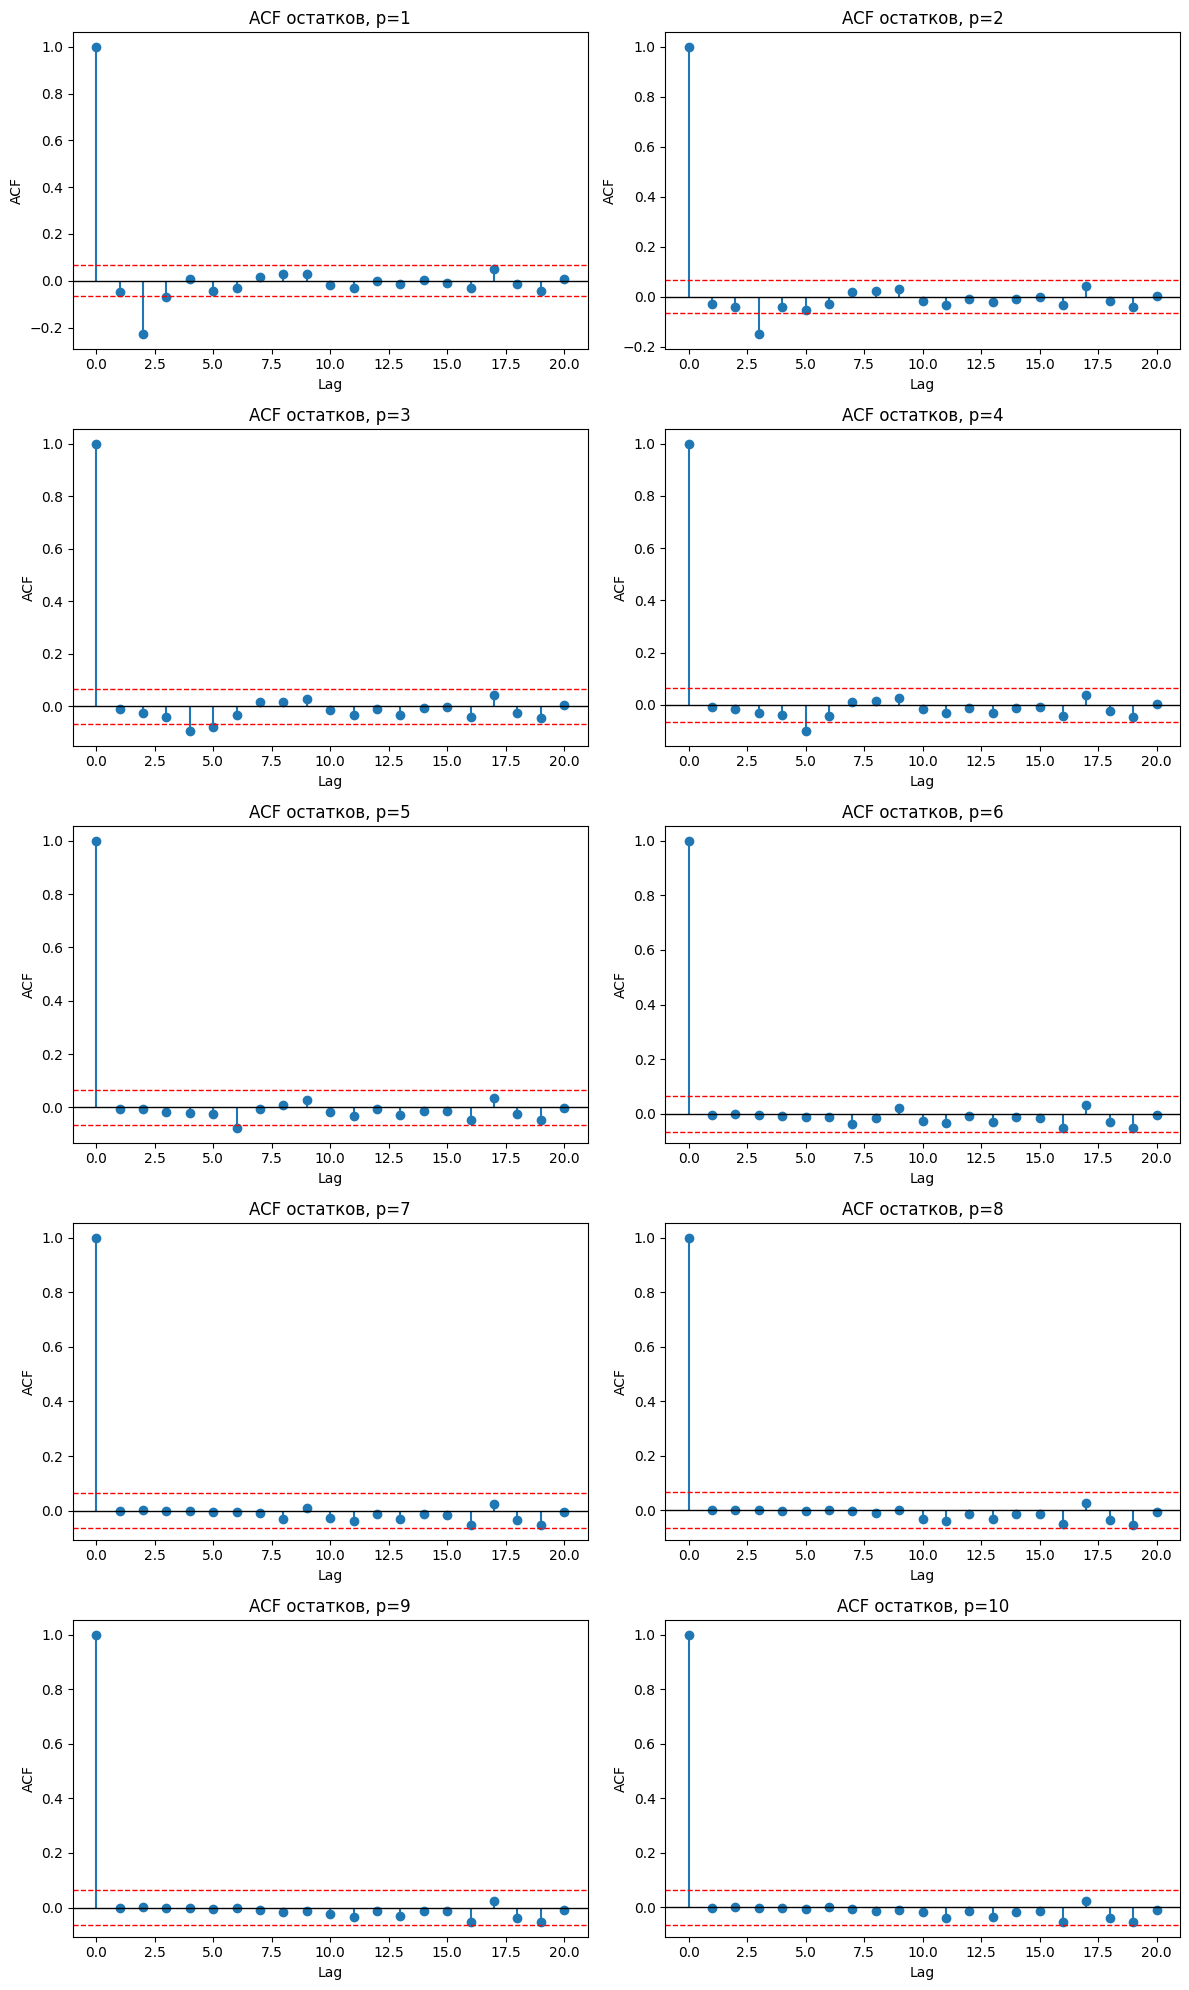

In [287]:
fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()

for idx, p in enumerate(range(1, max_p + 1)):
    X, y_dep = build_lag_matrix(dP, p)
    Xc       = sm.add_constant(X)
    model    = sm.OLS(y_dep, Xc).fit()
    resid    = model.resid

    acf_vals = sm_acf(resid, nlags=acf_lags, fft=False)

    axes[idx].stem(np.arange(acf_lags+1), acf_vals, basefmt=" ")
    # доверительные границы
    axes[idx].axhline( conf_bound, color='red', linestyle='--', linewidth=1)
    axes[idx].axhline(-conf_bound, color='red', linestyle='--', linewidth=1)
    # линия y=0
    axes[idx].axhline(0, color='black', linewidth=1)
    
    axes[idx].set_title(f'ACF остатков, p={p}')
    axes[idx].set_xlabel('Lag')
    axes[idx].set_ylabel('ACF')

plt.tight_layout()
plt.show()

- дают ли три рассмотренных метода подбора порядка модели одинаковые результаты?

In [288]:
p1 = p_estimate
p2 = p_selected
p3 = p3          

print(f"p1 (PACF): {p1}")
print(f"p2 (t-тест последнего коэффициента): {p2}")
print(f"p3 (ACF остатков): {p3}")

if p1 == p2 == p3:
    print("Все три метода дали одинаковый порядок модели.")
else:
    print("Методы дали разные результаты:")
    for name, val in [("PACF", p1), ("t-тест", p2), ("остатки", p3)]:
        print(f"  {name}: p = {val}")


p1 (PACF): 6
p2 (t-тест последнего коэффициента): 6
p3 (ACF остатков): 6
Все три метода дали одинаковый порядок модели.


- перейдите от разностей к исходному ряду давлений P и постройте прогноз с упреждением в 10 минут.

Пусть $P_t$ — исходный ряд давления, а 
$$
\Delta P_t = P_t - P_{t-1} = (1-L)P_t
$$
— его первая разность. Предположим, что для $\Delta P_t$ оценена авторегрессия порядка $p$:
$$
\Delta P_t = a_1\,\Delta P_{t-1} + a_2\,\Delta P_{t-2} + \cdots + a_p\,\Delta P_{t-p} + \varepsilon_t,
$$
что в операторной форме записывается как
$$
\Bigl(1 - \sum_{i=1}^p a_i L^i\Bigr)\,\Delta P_t = \varepsilon_t,\quad
A(L)\equiv 1 - \sum_{i=1}^p a_i L^i.
$$

Рекуррентный прогноз разностей.

Для горизонта $h$ шагов (в нашем случае $10$ минут, то есть $h=150$ при шаге $\Delta t=4$ с) прогноз $\hat\Delta P_{t+k}$ строится по
$$
  \hat\Delta P_{t+k}
  = a_1\,\Delta P_{t+k-1} + \cdots + a_p\,\Delta P_{t+k-p},
  \quad k=1,2,\dots,h,
$$
где при $k>1$ в правой части уже используются ранее спрогнозированные значения $\hat\Delta P$.

Интеграция прогноза.

Так как $(1-L)P_t = \Delta P_t$, оператор $(1-L)^{-1}$ разлагается в степенной ряд
$$
  (1-L)^{-1} \;=\; \sum_{k=0}^{\infty} L^k,
$$
и прогноз уровня $P$ имеет вид
$$
  \hat P_{t+h}
  = (1-L)^{-1}\Bigl[\hat\Delta P_{t+1},\,\dots,\,\hat\Delta P_{t+h}\Bigr]
  = P_t + \sum_{k=1}^{h}\hat\Delta P_{t+k}.
$$
 


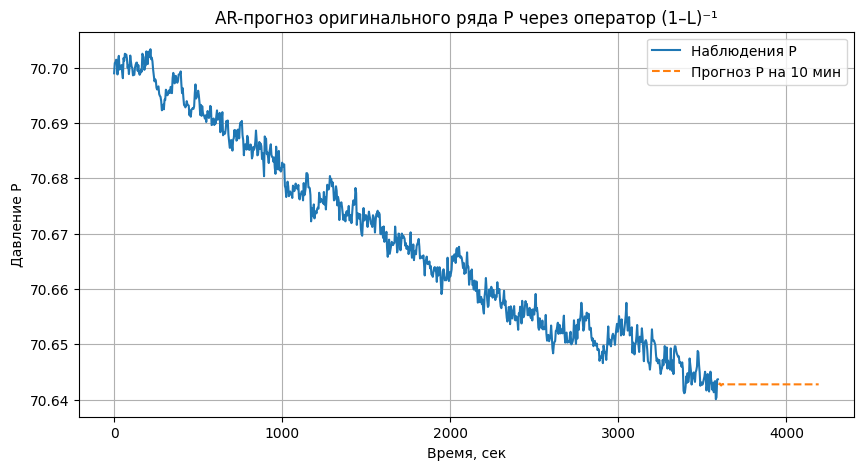

In [289]:
h_minutes = 10
step_sec = 4
h = int(h_minutes*60/step_sec)

X, y_dep = build_lag_matrix(dP, p_selected)

Xc = sm.add_constant(X)

ar_mod = sm.OLS(y_dep, Xc).fit()

coef = ar_mod.params[1:] 

history = list(dP) 
dP_forecast = []
for k in range(h):
    x = sum(coef[j] * history[-j-1] for j in range(p_selected))
    dP_forecast.append(x)
    history.append(x)

dP_forecast = np.array(dP_forecast)

P_last = P[-1]
P_forecast = P_last + np.cumsum(dP_forecast)

t_last = time[-1]
time_forecast = t_last + np.arange(1, h+1) * step_sec

plt.figure(figsize=(10,5))
plt.plot(time, P, label='Наблюдения P')
plt.plot(time_forecast, P_forecast, '--', label=f'Прогноз P на {h_minutes} мин')
plt.xlabel('Время, сек')
plt.ylabel('Давление P')
plt.title('AR-прогноз оригинального ряда P через оператор (1–L)⁻¹')
plt.legend()
plt.grid()
plt.show()

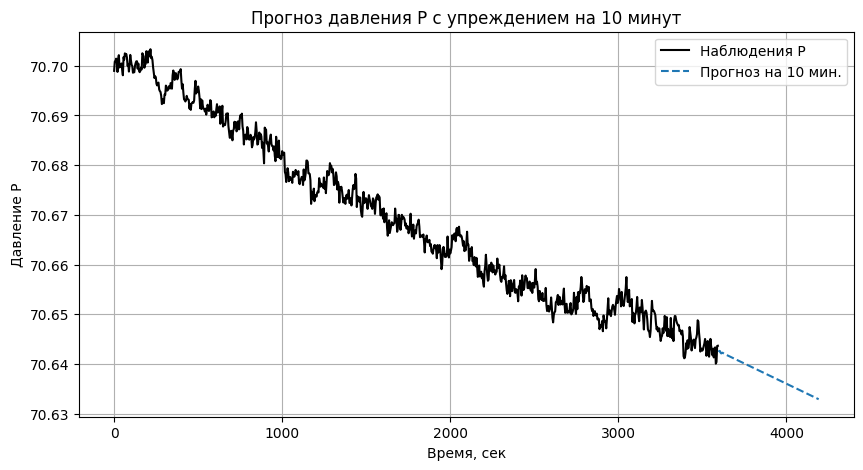

In [290]:
h_minutes = 10
step_sec = 4
h = int(h_minutes*60/step_sec)


ar_mod = AutoReg(dP, lags=p_selected, old_names=False).fit()

start = len(dP)
end   = start + h - 1
dP_forecast = ar_mod.predict(start=start, end=end)

P_last = P[-1]
P_forecast = P_last + np.cumsum(dP_forecast)

t_last = time[-1]
time_forecast = t_last + np.arange(1, h+1)*step_sec

plt.figure(figsize=(10,5))
plt.plot(time, P, label='Наблюдения P', color='black')
plt.plot(time_forecast, P_forecast, '--', label=f'Прогноз на {h_minutes} мин.')
plt.xlabel('Время, сек')
plt.ylabel('Давление P')
plt.legend()
plt.title('Прогноз давления P с упреждением на 10 минут')
plt.grid(True)
plt.show()